In [ ]:
#IMPORTS FOR MODEL
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.preprocessing import image
from matplotlib import pyplot as plt

from google.colab import files
import zipfile
import os


In [ ]:

#Set Preproccess image size and Load/Unzip Dataset into its directories
img_height, img_width = 64, 64

with zipfile.ZipFile('Dataset.zip', 'r') as zip_ref:
  zip_ref.extractall('images/')

compost_dir = 'images/Dataset/Compost'
general_dir = 'images/Dataset/General'
recycle_dir = 'images/Dataset/Recycle'


In [ ]:
#Preprocess Data and each of their titles to a different number
def load_images(folder, label):
  imgs = []
  labels = []
  for filename in os.listdir(folder):
    if filename.endswith('.jpg'):
        img_path = os.path.join(folder, filename)
        img = image.load_img(img_path, target_size=(img_height, img_width))
        img_array = image.img_to_array(img)
        img_array = img_array.flatten() / 255.0
        imgs.append(img_array)
        labels.append(label)
  return np.array(imgs), np.array(labels)

compost_imgs, compost_labels = load_images(compost_dir, 0)
general_imgs, general_labels = load_images(general_dir, 1)
recycle_imgs, recycle_labels = load_images(recycle_dir, 2)


In [ ]:
# Combine images data
X_train = np.vstack((compost_imgs, general_imgs, recycle_imgs))

# Combine labels
y_train = np.hstack((compost_labels, general_labels, recycle_labels))


In [ ]:
#Creating ANN and Defining Layers
model = Sequential()
model.add(InputLayer(input_shape=(X_train.shape[1],)))    # input layer
model.add(Dense(64, activation='relu'))                    # hidden layer
model.add(Dense(3, activation='softmax'))                  # output layer

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       786,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 786,691 (3.00 MB)

 Trainable params: 786,691 (3.00 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert labels to catagorical waste formats
y_train_cat = to_categorical(y_train)

# Train model
history = model.fit(X_train, y_train_cat, epochs=50, verbose=1)


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3085 - loss: 6.7856 
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2514 - loss: 5.1141
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3587 - loss: 3.8274
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2773 - loss: 1.6387
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4410 - loss: 1.3062
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4394 - loss: 1.0763
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5739 - loss: 1.2449
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5246 - loss: 0.9855
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4957 - loss: 1.1637
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5200 - loss: 1.0188
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6202 - loss: 0.9480
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4527 - loss: 1.1354


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9537 - loss: 0.2847 


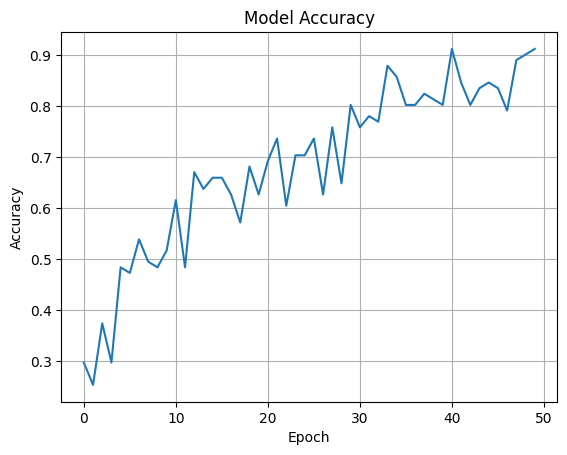

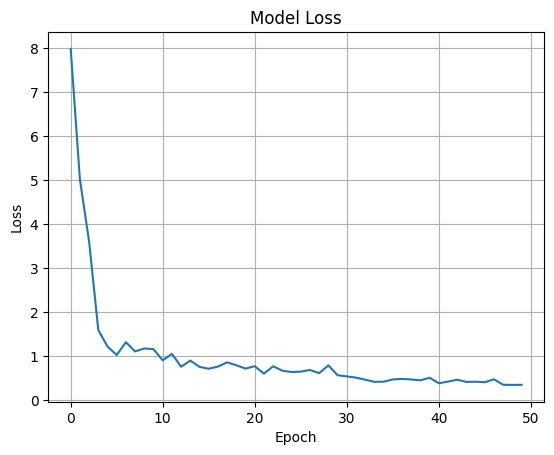

In [ ]:
#RESULTS FOR MODEL AFTER TRAINED

#Overall Model Eval
model.evaluate(X_train, y_train_cat)

#Accuracy Plot
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

#Loss Plot
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


In [ ]:
#UPLOAD TEST IMAGES

uploaded = files.upload()
test_filename = list(uploaded.keys())[0]

# Load and process Test image
img = image.load_img(test_filename, target_size=(64, 64))
img_array = image.img_to_array(img)
img_array = img_array.flatten() / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make a Waste Classification Prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)  # Highest Probability

# Waste Classes
classes = ['Compost', 'General', 'Recycle']

print("Classification of Waste:", classes[predicted_class])